# Unsupervised Learning

## Data Load And Importing Library

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import datetime
import math
from sklearn.preprocessing import StandardScaler
from mpl_toolkits import mplot3d

from yellowbrick.cluster import KElbowVisualizer

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
from ucimlrepo import fetch_ucirepo 

# fetch dataset 
online_retail = fetch_ucirepo(id=352) 

# data (as pandas dataframes) 
X = online_retail.data.features 
X = pd.concat([online_retail.data.ids, online_retail.data.features], axis=1)
# variable information 
print(online_retail.variables) 
print(online_retail.meta_data)


          name     role         type demographic  \
0    InvoiceNo       ID  Categorical        None   
1    StockCode       ID  Categorical        None   
2  Description  Feature  Categorical        None   
3     Quantity  Feature      Integer        None   
4  InvoiceDate  Feature         Date        None   
5    UnitPrice  Feature   Continuous        None   
6   CustomerID  Feature  Categorical        None   
7      Country  Feature  Categorical        None   

                                         description     units missing_values  
0  a 6-digit integral number uniquely assigned to...       NaN             no  
1  a 5-digit integral number uniquely assigned to...       NaN             no  
2                                       product name       NaN             no  
3  the quantities of each product (item) per tran...       NaN             no  
4  the day and time when each transaction was gen...       NaN             no  
5                             product price per uni

&nbsp;

In [3]:
X.head(-25)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541879,581585,22726,ALARM CLOCK BAKELIKE GREEN,8,12/9/2011 12:31,3.75,15804.0,United Kingdom
541880,581585,22727,ALARM CLOCK BAKELIKE RED,4,12/9/2011 12:31,3.75,15804.0,United Kingdom
541881,581585,16016,LARGE CHINESE STYLE SCISSOR,10,12/9/2011 12:31,0.85,15804.0,United Kingdom
541882,581585,21916,SET 12 RETRO WHITE CHALK STICKS,24,12/9/2011 12:31,0.42,15804.0,United Kingdom


&nbsp;

## Data Preprocessing and Transformation

### Handle Missing Values

In [4]:
X = X.dropna(subset=['CustomerID'])
X['CustomerID'] = X['CustomerID'].astype(int)
X

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680,France


&nbsp;

### Filter Return

In [5]:
X = X[~X['InvoiceNo'].astype(str).str.startswith('C')]
X

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680,France


&nbsp;

### Creating Total Price Feature

In [6]:
X['TotalPrice'] = X['UnitPrice'] * X['Quantity']
X

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680,France,16.60


&nbsp;

### Creating Recency Feature

In [7]:
X['InvoiceDate'] = pd.to_datetime(X['InvoiceDate'])

reference_date = pd.to_datetime(X['InvoiceDate'].max()) + datetime.timedelta(days=1)
X['Recency'] = (reference_date - X.groupby('CustomerID')['InvoiceDate'].transform('max')).dt.days
X

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Recency
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,372
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,372
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,372
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,372
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,372
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20,1
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,1
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,1
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,1


&nbsp;

### Creating Frequency Feature

In [8]:
X['Frequency'] = X.groupby('CustomerID')['InvoiceNo'].transform('nunique')
X

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Recency,Frequency
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,372,34
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,372,34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,372,34
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,372,34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,372,34
...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20,1,4
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,1,4
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,1,4
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,1,4


&nbsp;

### Creating Monetary Feature

In [9]:
X['Monetary'] = X.groupby('CustomerID')['TotalPrice'].transform('sum')
X

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Recency,Frequency,Monetary
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,372,34,5391.21
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,372,34,5391.21
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,372,34,5391.21
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,372,34,5391.21
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,372,34,5391.21
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20,1,4,862.81
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,1,4,862.81
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,1,4,862.81
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,1,4,862.81


&nbsp;

### Creating RFM Table

In [10]:
rfm_table = X[['CustomerID', 'Recency', 'Frequency', 'Monetary']].drop_duplicates()
rfm_table.set_index('CustomerID', inplace=True)
rfm_table.sort_index()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40
...,...,...,...
18280,278,1,180.60
18281,181,1,80.82
18282,8,2,178.05


In [11]:
rfm_table.describe().loc[['min', 'mean', '50%', 'max']]

,Recency,Frequency,Monetary
min,1.000000,1.000000,0.000000
mean,92.518322,4.271952,2053.793018
50%,51.000000,2.000000,674.450000
max,374.000000,210.000000,280206.020000


as we can see the data isnt really favorable, so we need to filter it

In [12]:
# Calculate the extreeme data
monetary_cutoff = rfm_table['Monetary'].quantile(0.90)
frequency_cutoff = rfm_table['Frequency'].quantile(0.90)

# Filter the data: Keep only the bottom 99%
rfm_table = rfm_table[
    (rfm_table['Monetary'] <= monetary_cutoff) & (rfm_table['Frequency'] <= frequency_cutoff)
]

rfm_table.describe().loc[['min', 'mean', '50%', 'max']]

,Recency,Frequency,Monetary
min,1.000000,1.000000,0.000000
mean,102.244995,2.634879,832.412591
50%,60.000000,2.000000,560.220000
max,374.000000,9.000000,3641.240000


## EDA

This Dataset used for RFM analysis, so the EDA basically gonna try do seek round something that useful in view of recency

### Plot for the RFM Feature

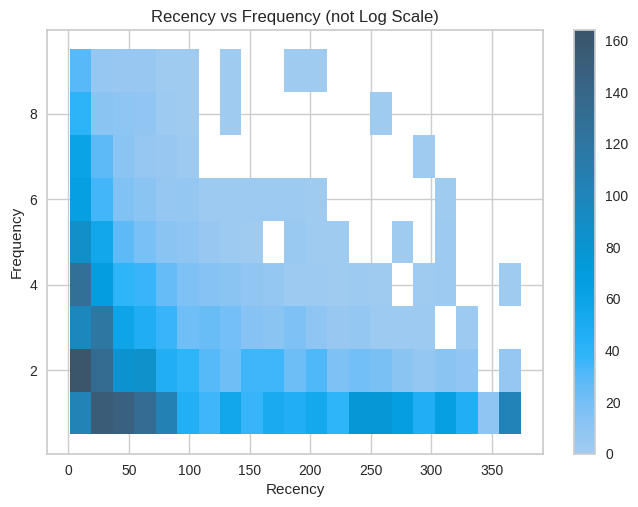

In [13]:
sns.histplot(
    data=rfm_table, 
    x='Recency', 
    y='Frequency', 
    log_scale=(False, False),  # Logs the Frequency axis, keeps Recency normal
    cbar=True,  # Adds a color bar so you can read the density,
    discrete=(False, True)
)
plt.title('Recency vs Frequency (not Log Scale)')
plt.show()

The bottom left corner is more crowded which imply that more people just hoping by that lead to high churn rate

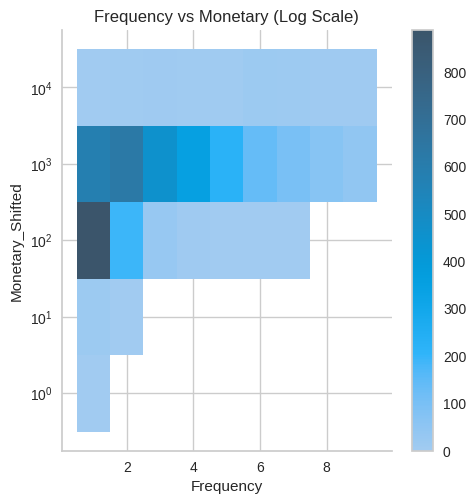

In [14]:
# Shifted the monetary data so it can be log scaled
min_monetary = rfm_table['Monetary'].min()
rfm_table['Monetary_Shifted'] = rfm_table['Monetary'] + abs(min_monetary) + 1

sns.displot(
    data=rfm_table, 
    x='Frequency', 
    y='Monetary_Shifted', 
    log_scale=(False, True),  # Logs the y axis, keeps Recency normal
    cbar=True,  # Adds a color bar so you can read the density,
    discrete=True
)
plt.title('Frequency vs Monetary (Log Scale)')
plt.show()

this one actualy interesting, the dist crowded on the bottom up left, which mean people that less come to buy spend more money

&nbsp;

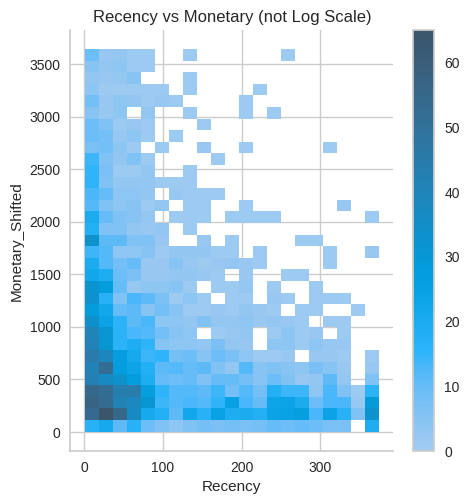

In [15]:
# shift up monetary data since there exist 0.0 data point
min_monetary = rfm_table['Monetary'].min()
rfm_table['Monetary_Shifted'] = rfm_table['Monetary'] + abs(min_monetary) + 1

sns.displot(
    data=rfm_table, 
    x='Recency', 
    y='Monetary_Shifted', 
    log_scale=(False, False),  # Logs the y axis, keeps Recency normal
    cbar=True,  # Adds a color bar so you can read the density,
)
plt.title('Recency vs Monetary (not Log Scale)')
plt.show()

the total spend of the customer is still healthy proved by the monetary that on the middle of the distribution, the recency dist still follow like before

&nbsp;

&nbsp;

## Data Scaling and Standardization

In [16]:
rfm_log = np.log(rfm_table[['Recency', 'Frequency', 'Monetary_Shifted']])
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [17]:
pd.DataFrame(rfm_scaled)

,0,1,2
0,0.447084,1.290064,0.568754
1,1.386256,0.544301,0.489185
2,0.381541,1.781286,1.321113
3,1.471462,-1.059583,-0.094657
4,-0.044293,0.544301,0.107386
...,...,...,...
3791,-2.468975,-1.059583,-1.007207
3792,-2.468975,-1.059583,-0.449996
3793,-2.991102,-1.059583,-0.402973
3794,-2.991102,-1.059583,-0.863133


## Finding K

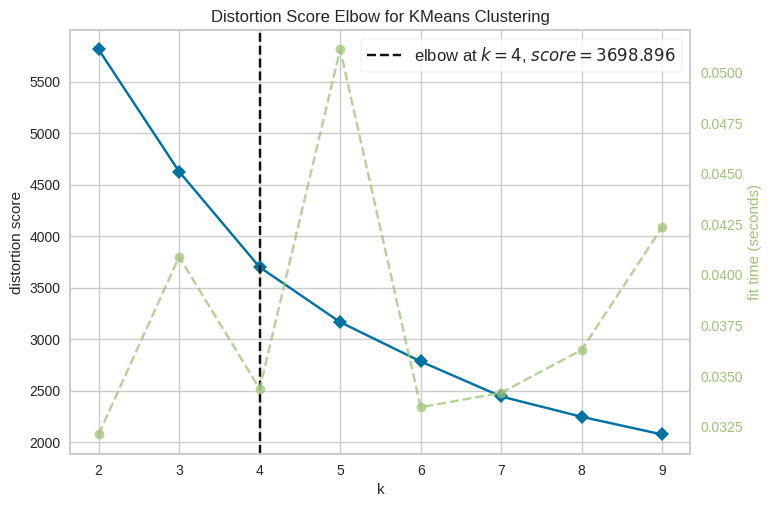

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [18]:
kmean = KMeans(n_init=10)
visualizer = KElbowVisualizer(kmean, k=(2, 10), force_model=True)
visualizer.fit(rfm_scaled)

visualizer.show()

&nbsp;

## K-Mean Cluster Modeling

In [19]:
kmeans = KMeans(n_clusters=5, random_state=0)
kmeans.fit(rfm_scaled)

labels = kmeans.labels_
pd.DataFrame(labels)

,0
0,0
1,1
2,0
3,4
4,1
...,...
3791,3
3792,3
3793,3
3794,3


<Axes: ylabel='Count'>

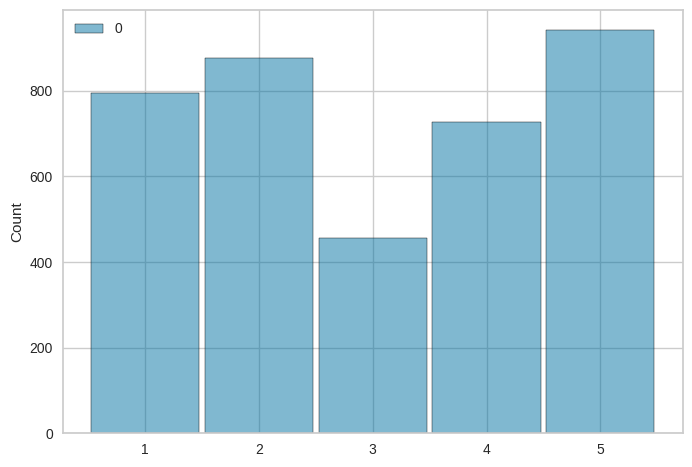

In [20]:
# Looking for the cluster dist
sns.histplot(pd.DataFrame(labels+1), discrete=(True, False), shrink=0.95)

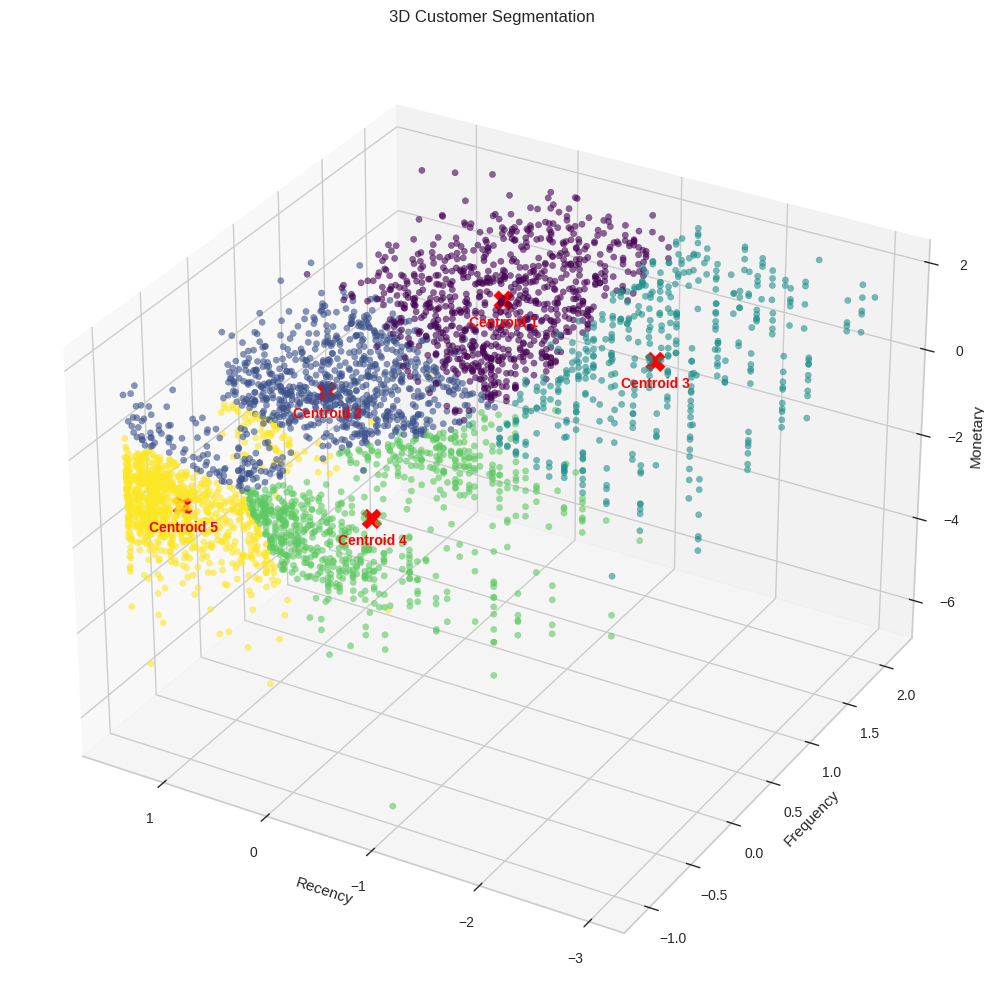

In [100]:
labels = kmeans.labels_
centroids = kmeans.cluster_centers_


fig = plt.figure(figsize=(10, 15))
ax = plt.axes(projection='3d')

z = rfm_scaled.transpose()[2]
x = rfm_scaled.transpose()[0]
y = rfm_scaled.transpose()[1]

# scatter = ax.scatter(x, y, z, c=rfm_table['Cluster'], cmap='viridis', s=20, alpha=0.6)

centers = ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], c='red', s=200, marker='X', label='Centroids', alpha=1)
for idx, center in enumerate(centroids):
    ax.text(center[0], center[1], center[2]-0.5, f'Centroid {idx+1}', color='red', fontsize=10, ha='center', va='center', fontweight='bold')
scatter = ax.scatter(x, y, z, c=labels, cmap='viridis', s=20, alpha=0.6)



ax.set_title('3D Customer Segmentation')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary', linespacing=3)
ax.invert_xaxis()
plt.tight_layout()
plt.show()

### Statistic Each Cluster

In [77]:
rfm_table = pd.DataFrame(rfm_table)
rfm_table['Cluster'] = labels
rfm_table.rename(columns={0: 'Recency'}, inplace=True)
rfm_table.rename(columns={1: 'Frequency'}, inplace=True)
rfm_table.rename(columns={2: 'Monetary'}, inplace=True)

In [78]:
summary = rfm_table.drop(columns=['Monetary_Shifted']).groupby('Cluster').describe().stack(level=0).loc[:, ['min', 'mean', '50%', 'max']]
summary

min         mean      50%      max
Cluster                                                 
0       Recency     12.00    48.416352    34.00   302.00
        Frequency    2.00     4.874214     5.00     9.00
        Monetary   414.76  1685.631360  1521.76  3641.24
1       Recency     18.00   126.429875   105.00   372.00
        Frequency    1.00     2.256556     2.00     6.00
        Monetary   167.50   804.842397   689.95  3528.34
2       Recency      1.00     6.479121     6.00    17.00
        Frequency    1.00     4.683516     4.00     9.00
        Monetary   201.12  1443.496659  1258.06  3640.67
3       Recency      1.00    32.821183    29.00    82.00
        Frequency    1.00     1.368638     1.00     4.00
        Monetary     0.00   321.222684   300.02  1201.49
4       Recency     45.00   224.992569   234.00   374.00
        Frequency    1.00     1.084926     1.00     6.00
        Monetary     3.75   237.361582   207.65   754.87

&nbsp;

### Visualizing Each Cluster

#### Dist for all data for different cluster

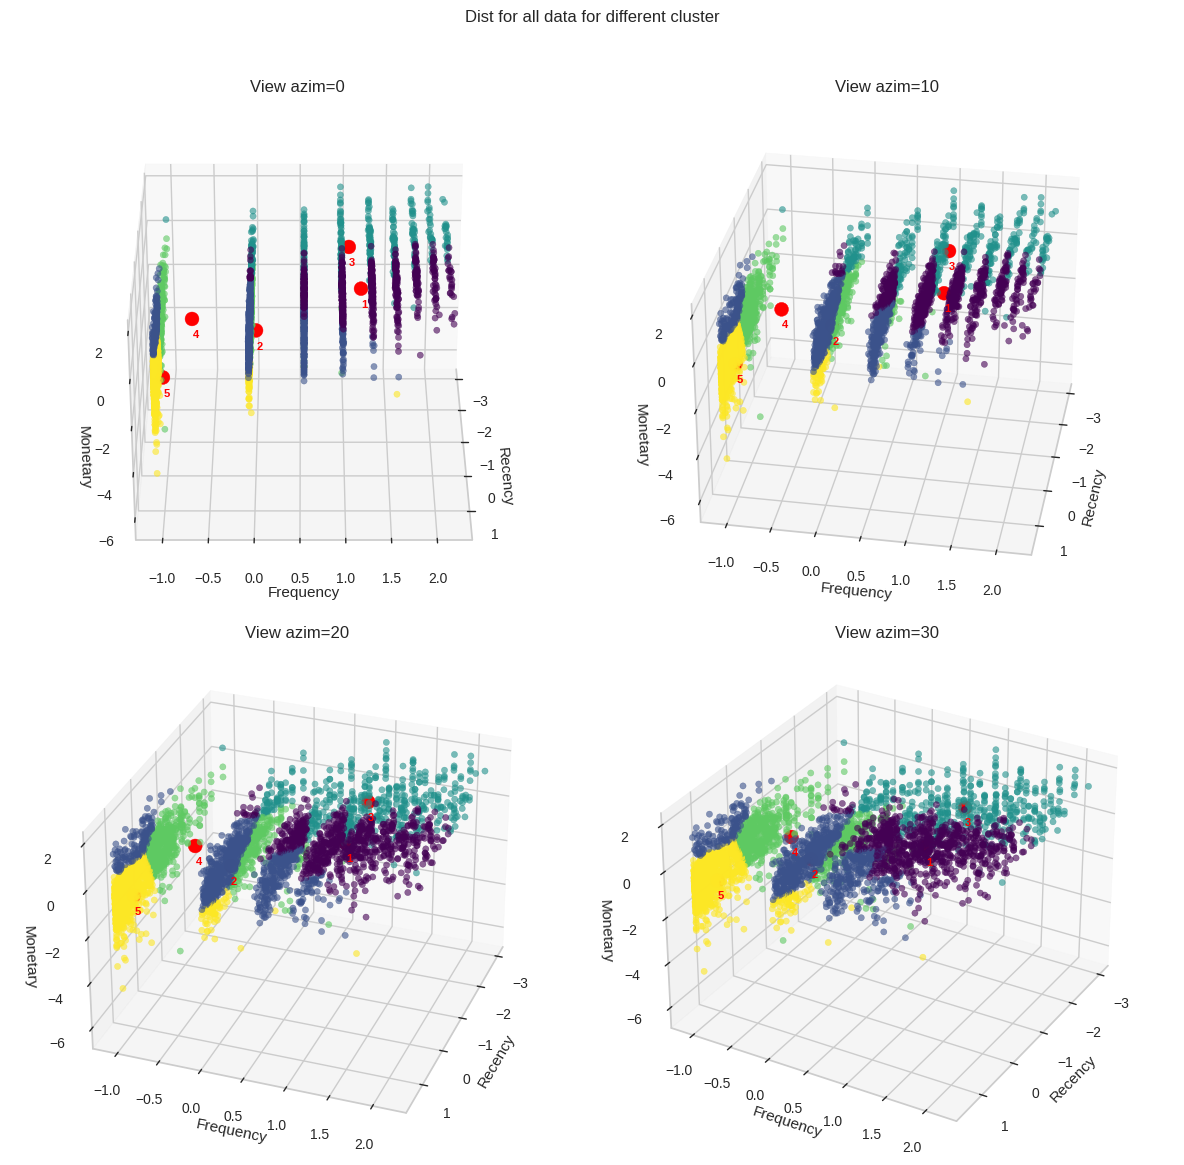

In [127]:
n_total_plot = 4
n_column = 2
n_rows = math.ceil(n_total_plot / n_column)

fig = plt.figure(figsize=(12, 12))

z = rfm_scaled.transpose()[2]
x = rfm_scaled.transpose()[0]
y = rfm_scaled.transpose()[1]

plt.title('Dist for all data for different cluster\n\n\n\n')
plt.axis('off')
for i in range(n_total_plot):
    ax = fig.add_subplot(n_rows, n_column, i + 1, projection='3d')


    scatter = ax.scatter(x, y, z, c=labels, cmap='viridis', s=20, alpha=0.6)
    ax.view_init(elev=30, azim=i*10)


    ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], c='red', s=100, marker='o', label='Centroids', alpha=1)
    for idx, center in enumerate(centroids):
        ax.text(center[0], center[1], center[2]-0.8, f'{idx+1}', color='red', fontsize=8, fontweight='bold')

    ax.set_title(f"View azim={i*10}")
    ax.set_xlabel('Recency')
    ax.set_ylabel('Frequency')
    ax.set_zlabel('Monetary', linespacing=3)

plt.tight_layout()
plt.show()

&nbsp;

In [135]:
rfm_scaled_pd = pd.DataFrame(rfm_scaled)
rfm_scaled_pd['CLuster'] = labels

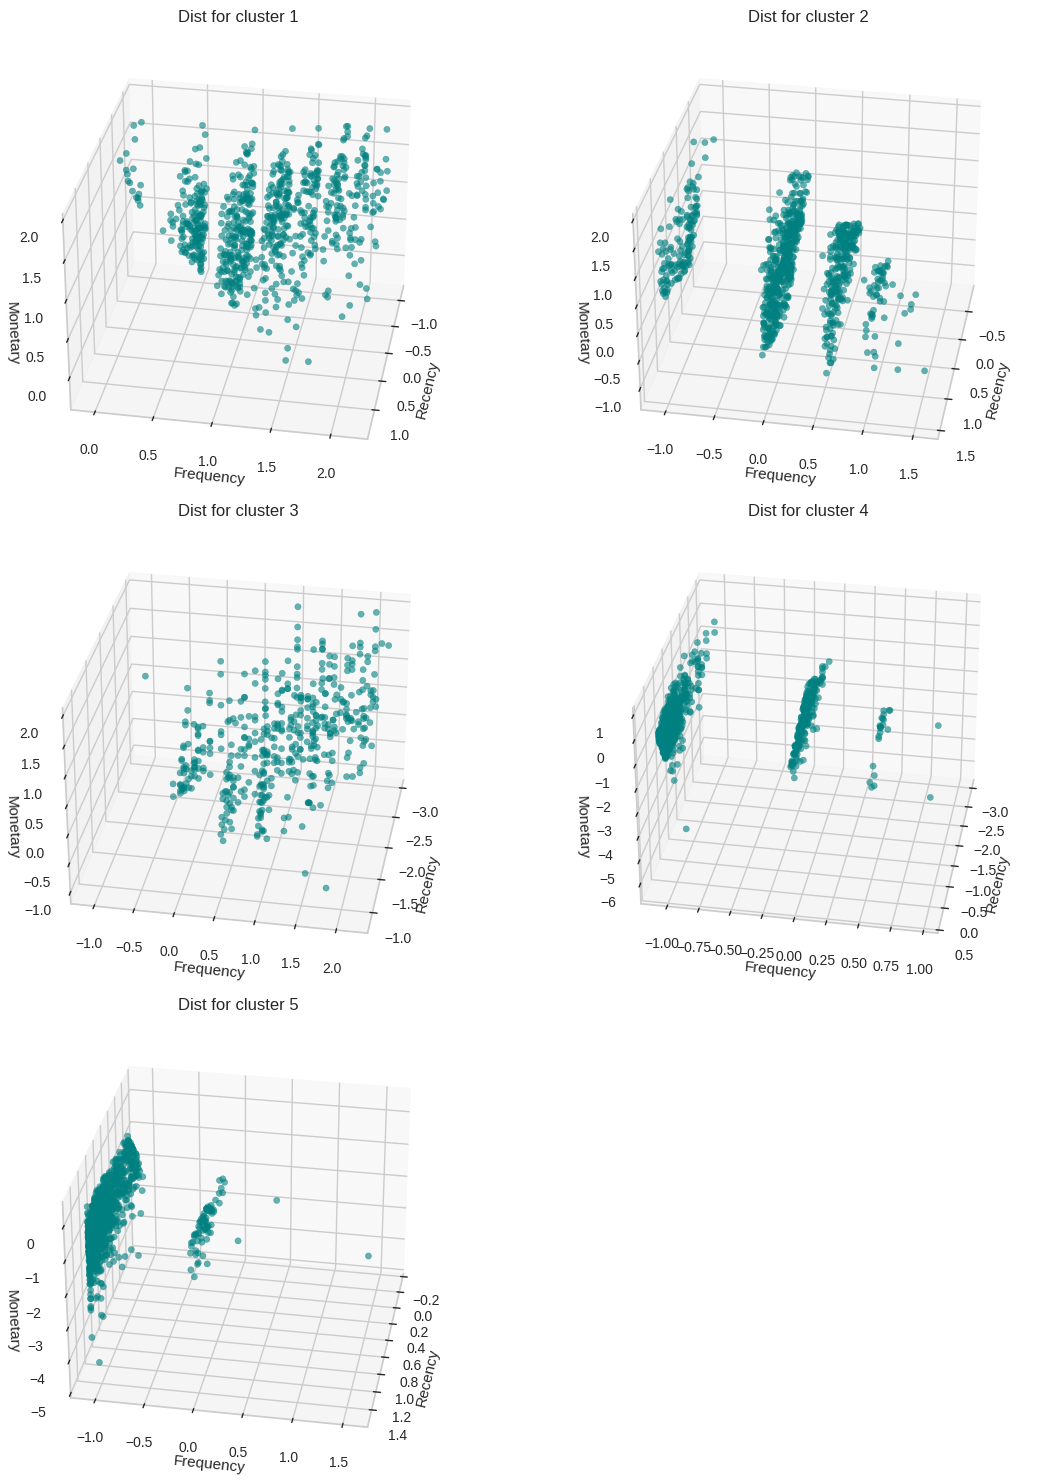

In [145]:
unique_clusters = sorted(rfm_scaled_pd['CLuster'].unique())
n_total_plot = len(unique_clusters)
n_column = 2
n_rows = math.ceil(n_total_plot / n_column)

fig = plt.figure(figsize=(12, n_rows * 5))

for i, cluster_id in enumerate(unique_clusters):
    ax = fig.add_subplot(n_rows, n_column, i + 1, projection='3d')

    cluster_data = rfm_scaled_pd[rfm_scaled_pd['CLuster'] == cluster_id]

    ax.scatter(cluster_data[0], 
               cluster_data[1], 
               cluster_data[2],
               c='teal', 
               s=20, 
               alpha=0.6)

    ax.view_init(elev=30, azim=10)
    ax.set_title(f"Dist for cluster {i+1}")
    ax.set_xlabel('Recency')
    ax.set_ylabel('Frequency')
    ax.set_zlabel('Monetary', linespacing=3)

plt.tight_layout()
plt.show()